In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("energydata_complete.csv")

# Display basic info
df.head()


,S:No,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,1,11-01-2016,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2,11-01-2016,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,3,11-01-2016,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,4,11-01-2016,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,5,11-01-2016,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   S:No         19735 non-null  int64  
 1   date         19735 non-null  object 
 2   Appliances   19735 non-null  int64  
 3   lights       19735 non-null  int64  
 4   T1           19735 non-null  float64
 5   RH_1         19735 non-null  float64
 6   T2           19735 non-null  float64
 7   RH_2         19735 non-null  float64
 8   T3           19735 non-null  float64
 9   RH_3         19735 non-null  float64
 10  T4           19735 non-null  float64
 11  RH_4         19735 non-null  float64
 12  T5           19735 non-null  float64
 13  RH_5         19735 non-null  float64
 14  T6           19735 non-null  float64
 15  RH_6         19735 non-null  float64
 16  T7           19735 non-null  float64
 17  RH_7         19735 non-null  float64
 18  T8           19735 non-null  float64
 19  RH_8

,S:No,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,9868.000000,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,19.485828,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033
std,5697.148117,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,2.014712,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634
min,1.000000,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,4934.500000,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,18.000000,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,9868.000000,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,19.390000,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653
75%,14801.500000,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,20.600000,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769
max,19735.000000,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [4]:
# Convert date safely
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['date'])

# Extract features
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

# Drop date column
df.drop('date', axis=1, inplace=True)

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Preprocessing done ")

Preprocessing done 


# Exploratory Data Analysis

Correlation Heatmap

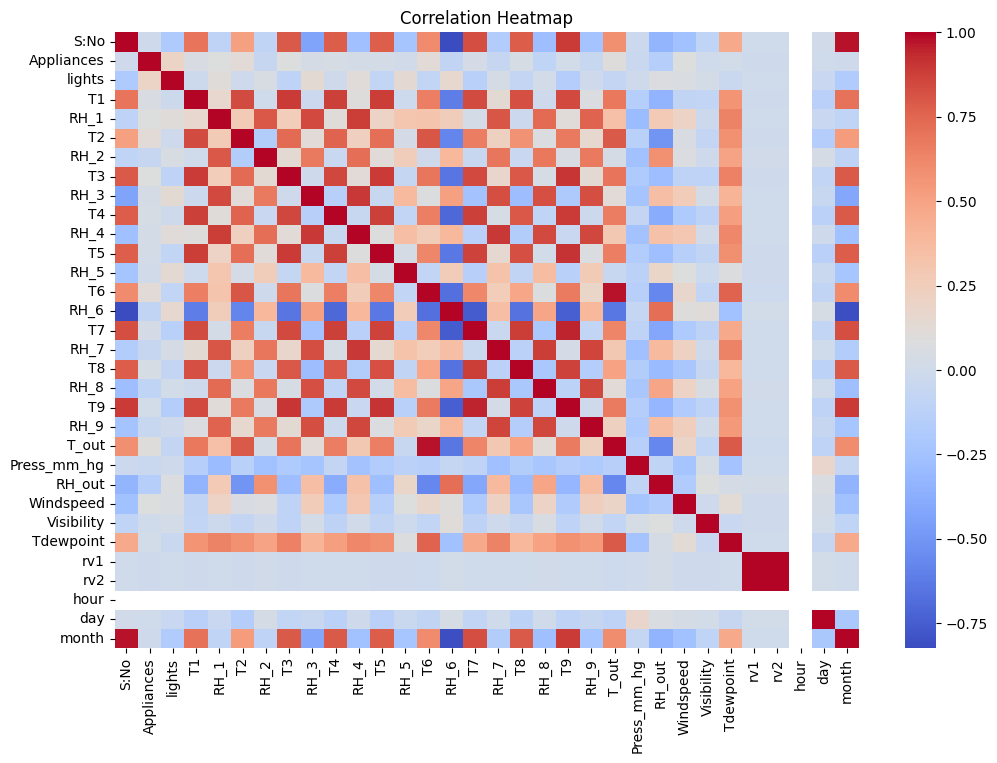

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Appliance Energy Distribution

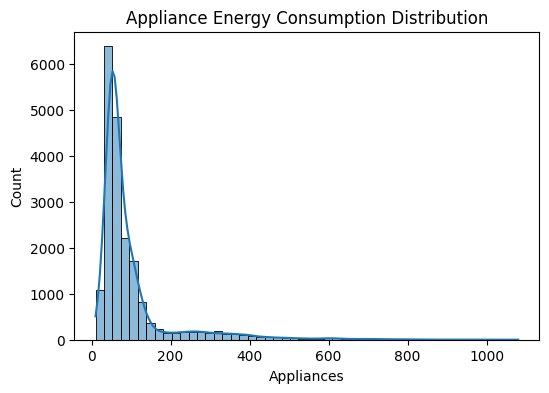

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title("Appliance Energy Consumption Distribution")
plt.show()

Plotly Visualization

In [7]:
px.histogram(df, x='Appliances', title="Energy Consumption Distribution").show()

px.scatter(df, x='T1', y='Appliances', title="Energy vs Temperature").show()

px.scatter(df, x='RH_1', y='Appliances', title="Energy vs Humidity").show()



# Feature Selection

In [8]:
X = df.drop('Appliances', axis=1)
y = df['Appliances']

# Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Selection

In [11]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

Model Comparision

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2 Score"])

# Sort best model on top
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

               Model          MSE  R2 Score
3      Random Forest  4670.643147  0.533267
5            XGBoost  5084.103027  0.491950
4  Gradient Boosting  7235.578748  0.276955
1   Ridge Regression  8310.971591  0.169492
0  Linear Regression  8314.982278  0.169091
2      Decision Tree  8437.952876  0.156803


# Best Model

In [13]:
best_model = results_df.iloc[0]

print("\nBest Model:")
print(f"Model: {best_model['Model']}")
print(f"R2 Score: {best_model['R2 Score']}")
print(f"MSE: {best_model['MSE']}")


Best Model:
Model: Random Forest
R2 Score: 0.5332666503390838
MSE: 4670.643146693691


# Visualization

R2 Score

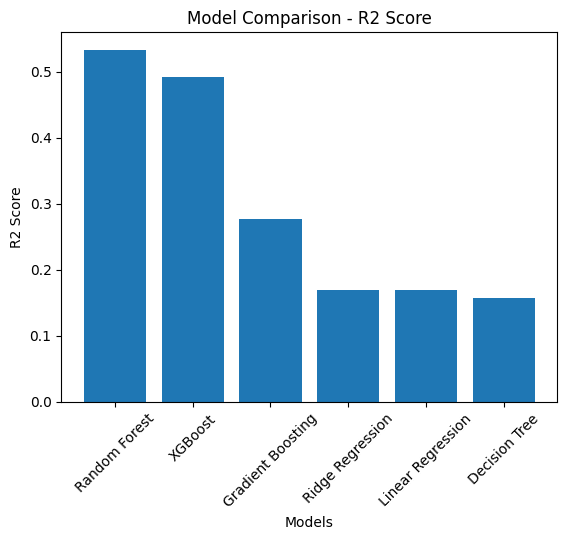

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison - R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

MSE

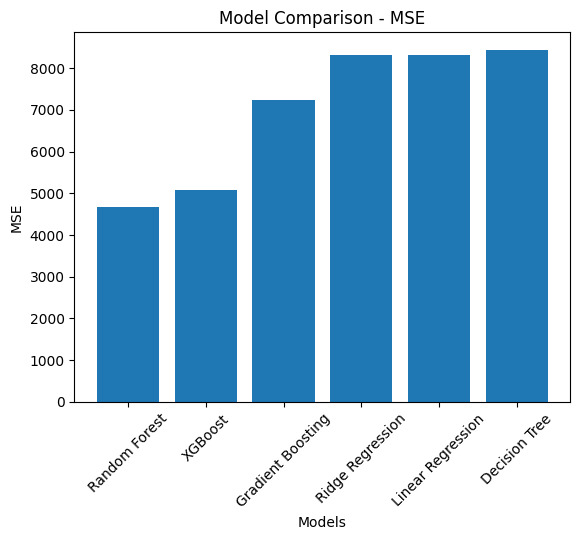

In [15]:
plt.figure()
plt.bar(results_df["Model"], results_df["MSE"])
plt.title("Model Comparison - MSE")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.xticks(rotation=45)
plt.show()

# Feature Importance

In [16]:
model = models["Random Forest"]   # make sure name matches your dictionary

# Get feature importance
importances = model.feature_importances_
features = X.columns

# Create DataFrame
feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df.head(10))

        Feature  Importance
0          S:No    0.062390
3          RH_1    0.061307
22       RH_out    0.060219
21  Press_mm_hg    0.048939
7          RH_3    0.047979
17         RH_8    0.047784
6            T3    0.046103
1        lights    0.043978
5          RH_2    0.043559
11         RH_5    0.043256


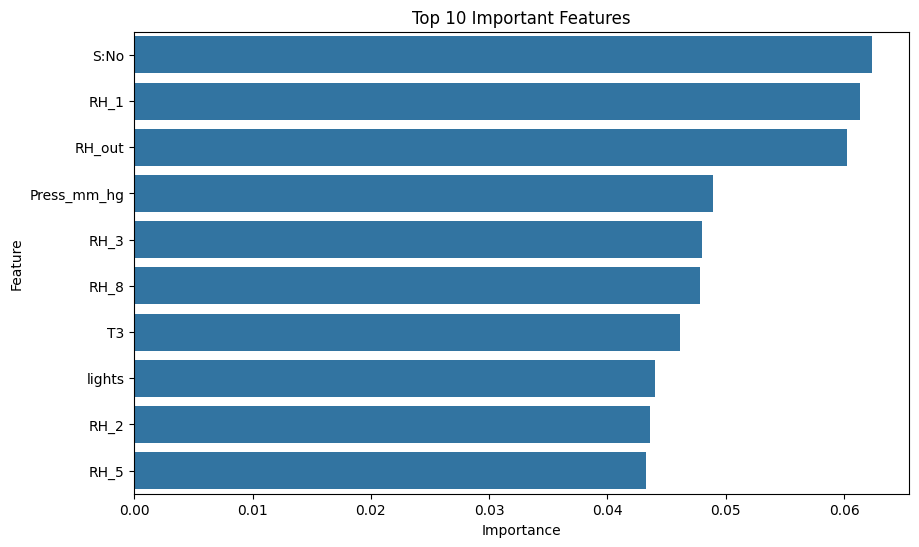

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

- Random Forest performed better than Linear Regression (lower MSE, higher R²).
- Environmental factors like temperature and humidity strongly influence energy usage.
- Time-based features (hour, day) also contribute to prediction accuracy.
- Model can be used for smart energy recommendations and grid optimization.

In [18]:
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
import joblib
joblib.dump(rf, "energy_model.pkl")

['energy_model.pkl']

In [20]:
import joblib
rf=RandomForestRegressor()
joblib.dump(rf, "energy_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [21]:
from sklearn.ensemble import RandomForestRegressor
import joblib

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Save model + feature names (IMPORTANT)
joblib.dump((rf, X.columns), "energy_model.pkl")

['energy_model.pkl']